# Network Intrusion Detection using NSL-KDD

## 1. Data Loading
Loading the NSL-KDD train and test datasets and assigning column names based on the dataset documentation.

In [1]:
import pandas as pd
import numpy as np

col_names = ["duration","protocol_type","service","flag","src_bytes",
    "dst_bytes","land","wrong_fragment","urgent","hot","num_failed_logins",
    "logged_in","num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files","num_outbound_cmds",
    "is_host_login","is_guest_login","count","srv_count","serror_rate",
    "srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
    "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count",
    "dst_host_same_srv_rate","dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate","dst_host_srv_serror_rate",
    "dst_host_rerror_rate","dst_host_srv_rerror_rate","label"]

df = pd.read_csv("data/KDDTrain.csv", header=None, names=col_names)
df_test = pd.read_csv("data/KDDTest.csv", header=None, names=col_names)

print("Train shape:", df.shape)
print("Test shape:", df_test.shape)
df.head()

Train shape: (125973, 42)
Test shape: (22544, 42)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


## 2. Data Inspection
Checking feature data types, missing values, constant columns, and duplicate rows.

In [2]:
# Feature types check
print(df.dtypes)
print("\n--- Missing values ---")
print(df.isnull().sum().sum())

print("\n--- Constant columns ---")
for col in df.columns:
    if df[col].nunique() == 1:
        print("Constant column:", col)

print("\n--- Duplicate rows ---")
print(df.duplicated().sum())

print("\n--- Label distribution ---")
print(df['label'].value_counts())

duration                         int64
protocol_type                   object
service                         object
flag                            object
src_bytes                        int64
dst_bytes                        int64
land                             int64
wrong_fragment                   int64
urgent                           int64
hot                              int64
num_failed_logins                int64
logged_in                        int64
num_compromised                  int64
root_shell                       int64
su_attempted                     int64
num_root                         int64
num_file_creations               int64
num_shells                       int64
num_access_files                 int64
num_outbound_cmds                int64
is_host_login                    int64
is_guest_login                   int64
count                            int64
srv_count                        int64
serror_rate                    float64
srv_serror_rate          

## 3. Handling Irrelevant Features and Categorical Overview
Dropping the constant column found in the previous step, and reviewing the categorical features present in the dataset.

In [3]:
# Drop constant/irrelevant column
df = df.drop('num_outbound_cmds', axis=1)
df_test = df_test.drop('num_outbound_cmds', axis=1)

print("New shape after dropping constant column:", df.shape)

# Categorical columns check
categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical columns:", list(categorical_cols))

for col in categorical_cols:
    print(f"\n{col} unique values ({df[col].nunique()}):")
    print(df[col].unique())

New shape after dropping constant column: (125973, 41)

Categorical columns: ['protocol_type', 'service', 'flag', 'label']

protocol_type unique values (3):
['tcp' 'udp' 'icmp']

service unique values (70):
['ftp_data' 'other' 'private' 'http' 'remote_job' 'name' 'netbios_ns'
 'eco_i' 'mtp' 'telnet' 'finger' 'domain_u' 'supdup' 'uucp_path' 'Z39_50'
 'smtp' 'csnet_ns' 'uucp' 'netbios_dgm' 'urp_i' 'auth' 'domain' 'ftp'
 'bgp' 'ldap' 'ecr_i' 'gopher' 'vmnet' 'systat' 'http_443' 'efs' 'whois'
 'imap4' 'iso_tsap' 'echo' 'klogin' 'link' 'sunrpc' 'login' 'kshell'
 'sql_net' 'time' 'hostnames' 'exec' 'ntp_u' 'discard' 'nntp' 'courier'
 'ctf' 'ssh' 'daytime' 'shell' 'netstat' 'pop_3' 'nnsp' 'IRC' 'pop_2'
 'printer' 'tim_i' 'pm_dump' 'red_i' 'netbios_ssn' 'rje' 'X11' 'urh_i'
 'http_8001' 'aol' 'http_2784' 'tftp_u' 'harvest']

flag unique values (11):
['SF' 'S0' 'REJ' 'RSTR' 'SH' 'RSTO' 'S1' 'RSTOS0' 'S3' 'S2' 'OTH']

label unique values (23):
['normal' 'neptune' 'warezclient' 'ipsweep' 'portswee

## 4. Exploratory Data Analysis

### 4.1 Class Distribution
Checking the balance between normal and attack traffic.

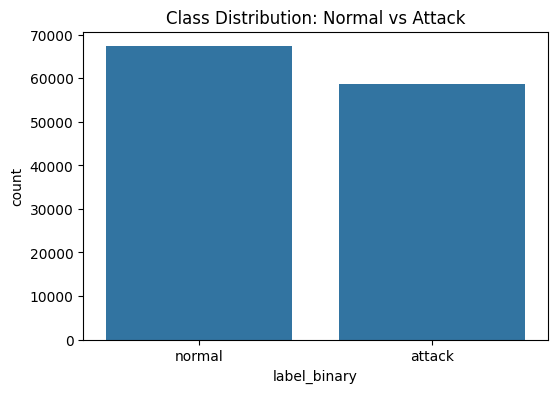

label_binary
normal    0.534583
attack    0.465417
Name: proportion, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Binary label (normal vs attack) for imbalance analysis
df['label_binary'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

plt.figure(figsize=(6,4))
sns.countplot(x='label_binary', data=df)
plt.title('Class Distribution: Normal vs Attack')
plt.savefig('class_distribution.png')
plt.show()

print(df['label_binary'].value_counts(normalize=True))

### 4.2 Attack Category Distribution
Grouping individual attack labels into standard categories (DoS, Probe, R2L, U2R) to better understand class imbalance.

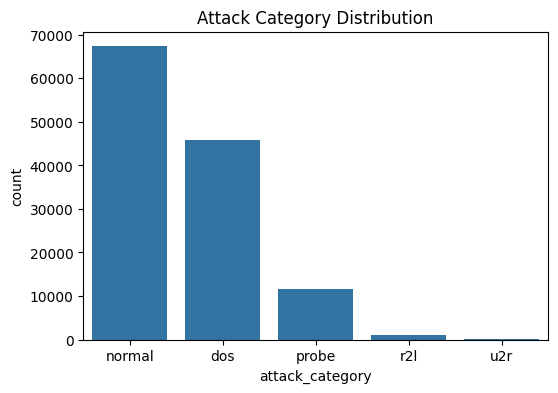

attack_category
normal    67343
dos       45927
probe     11656
r2l         995
u2r          52
Name: count, dtype: int64


In [5]:
# Attack category grouping (standard NSL-KDD mapping)
attack_map = {
    'normal':'normal',
    'neptune':'dos','back':'dos','land':'dos','pod':'dos','smurf':'dos','teardrop':'dos',
    'ipsweep':'probe','nmap':'probe','portsweep':'probe','satan':'probe',
    'ftp_write':'r2l','guess_passwd':'r2l','imap':'r2l','multihop':'r2l',
    'phf':'r2l','spy':'r2l','warezclient':'r2l','warezmaster':'r2l',
    'buffer_overflow':'u2r','loadmodule':'u2r','perl':'u2r','rootkit':'u2r'
}
df['attack_category'] = df['label'].map(attack_map)

plt.figure(figsize=(6,4))
sns.countplot(x='attack_category', data=df, order=df['attack_category'].value_counts().index)
plt.title('Attack Category Distribution')
plt.savefig('attack_category_distribution.png')
plt.show()

print(df['attack_category'].value_counts())

### 4.3 Numeric Feature Distributions
Reviewing summary statistics of the numeric features.

In [6]:
# Numeric feature distributions
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
df[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
duration,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
src_bytes,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
dst_bytes,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
land,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
wrong_fragment,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
urgent,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
hot,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
num_failed_logins,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
logged_in,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
num_compromised,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


### 4.4 Outlier Analysis
Checking selected features for outliers using boxplots on a log scale.

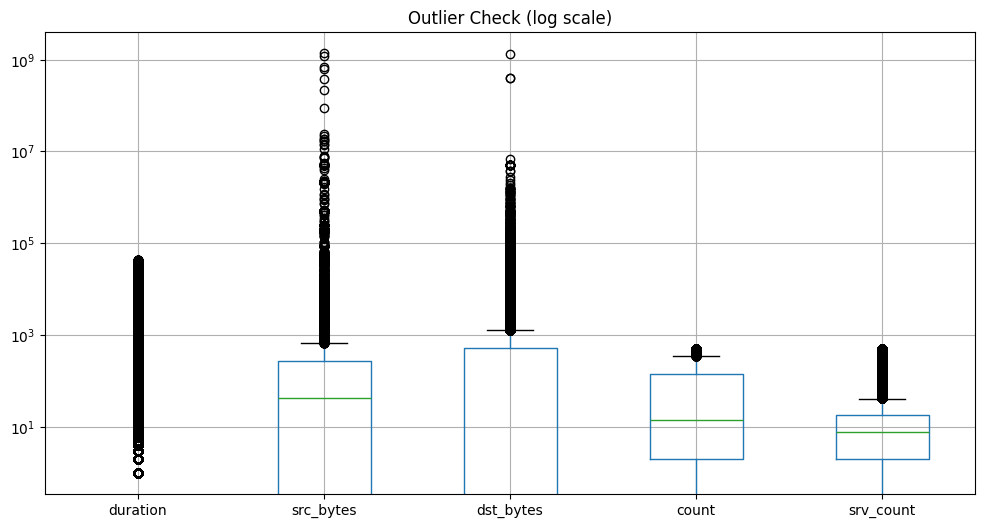

In [7]:
# Outlier check via boxplot on key features
key_features = ['duration','src_bytes','dst_bytes','count','srv_count']
plt.figure(figsize=(12,6))
df[key_features].boxplot()
plt.yscale('log')
plt.title('Outlier Check (log scale)')
plt.savefig('outlier_check.png')
plt.show()

### 4.5 Correlation Analysis
Using Pearson correlation since most features are continuous rate or count-based values.

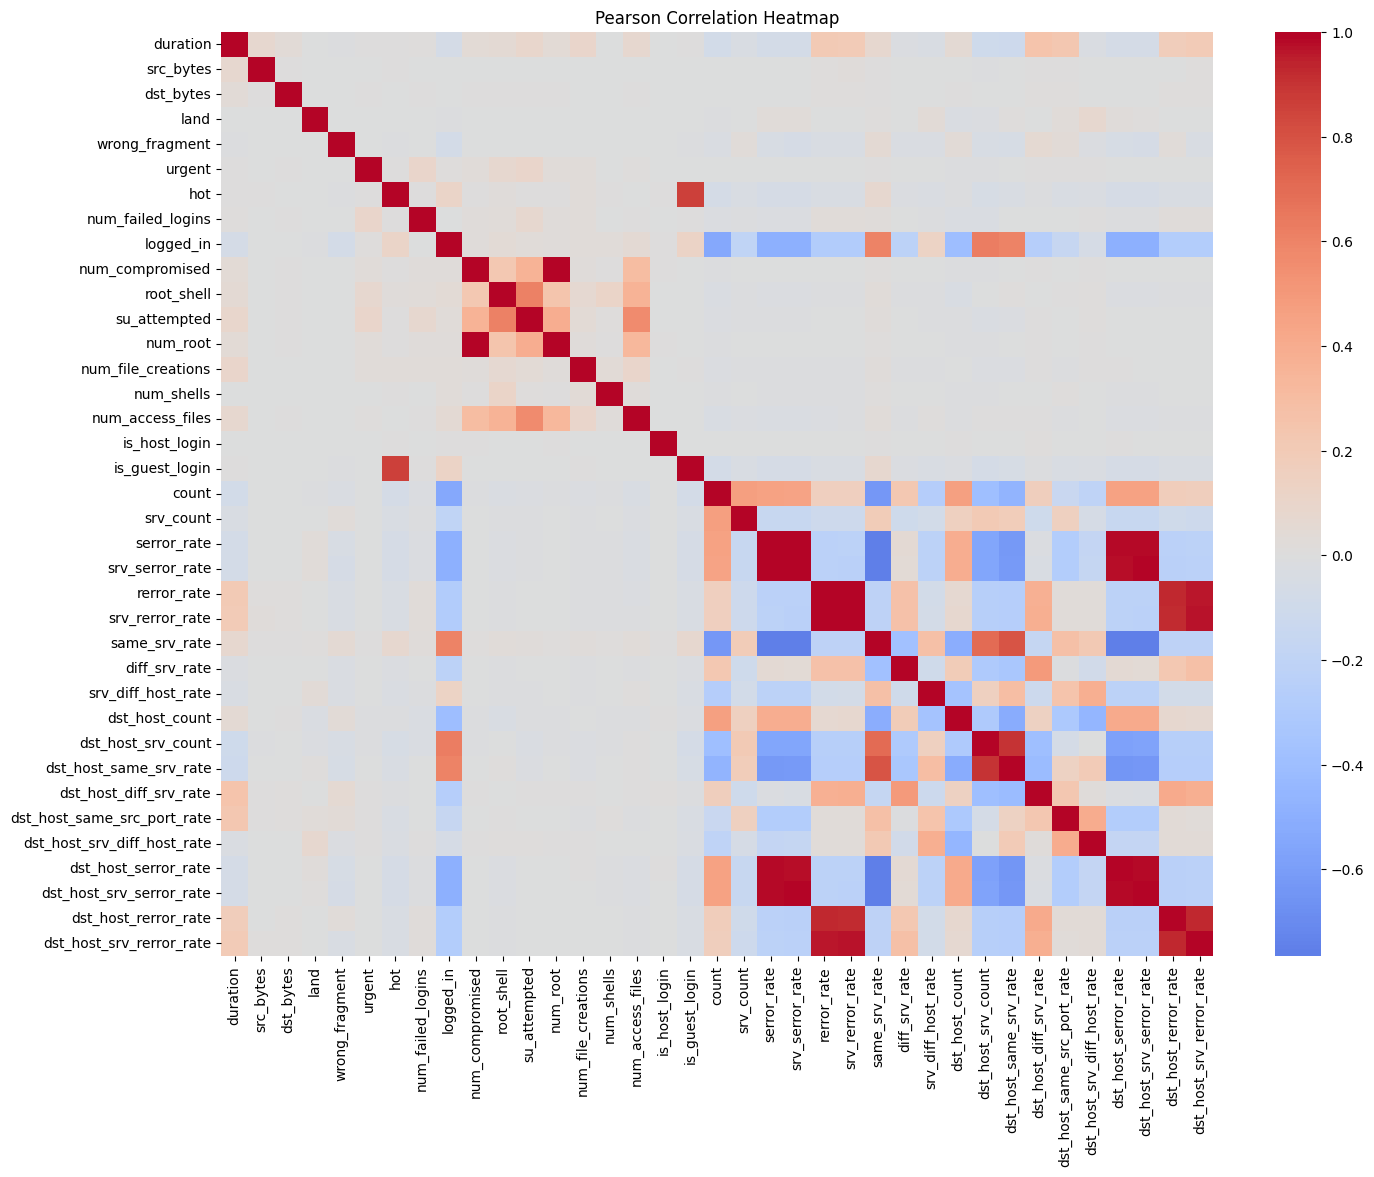

In [8]:
# Correlation analysis (Pearson, since features are mostly continuous rate/count data)
plt.figure(figsize=(16,12))
corr = df[numeric_cols].corr(method='pearson')
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Heatmap')
plt.savefig('correlation_heatmap.png')
plt.show()

### 4.6 Categorical Features vs Attack Category
Checking how protocol type and flag relate to different attack categories using crosstabs.

In [9]:
# Categorical vs label crosstab
for col in ['protocol_type','flag']:
    print(f"\n--- {col} vs attack_category ---")
    print(pd.crosstab(df[col], df['attack_category']))


--- protocol_type vs attack_category ---
attack_category    dos  normal  probe  r2l  u2r
protocol_type                                  
icmp              2847    1309   4135    0    0
tcp              42188   53600   5857  995   49
udp                892   12434   1664    0    3

--- flag vs attack_category ---
attack_category    dos  normal  probe  r2l  u2r
flag                                           
OTH                  0      11     35    0    0
REJ               5671    2693   2869    0    0
RSTO              1216     219     80   46    1
RSTOS0               0       0    103    0    0
RSTR                90     146   2180    5    0
S0               34344     354    153    0    0
S1                   2     361      1    1    0
S2                   5     119      2    1    0
S3                   0      45      1    3    0
SF                4599   63393   5967  935   51
SH                   0       2    265    4    0


### 4.7 Class Imbalance Summary
Summarizing the percentage share of each attack category.

In [10]:
# Class imbalance % summary (for report)
print(df['attack_category'].value_counts(normalize=True) * 100)

attack_category
normal    53.458281
dos       36.457812
probe      9.252776
r2l        0.789852
u2r        0.041279
Name: proportion, dtype: float64


### 4.8 Feature Redundancy Check
Identifying pairs of numeric features that are highly correlated with each other (above 0.9), which may indicate redundant information.

In [11]:
# Top correlated features with each other (redundancy check)
corr_matrix = df[numeric_cols].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper.loc[row,col]) for col in upper.columns for row in upper.index if upper.loc[row,col] > 0.9]
high_corr_df = pd.DataFrame(high_corr_pairs, columns=['Feature1','Feature2','Correlation']).sort_values('Correlation', ascending=False)
print(high_corr_df)

                    Feature1              Feature2  Correlation
0                   num_root       num_compromised     0.998833
1            srv_serror_rate           serror_rate     0.993289
2            srv_rerror_rate           rerror_rate     0.989008
6   dst_host_srv_serror_rate       srv_serror_rate     0.986252
7   dst_host_srv_serror_rate  dst_host_serror_rate     0.985052
5   dst_host_srv_serror_rate           serror_rate     0.981139
3       dst_host_serror_rate           serror_rate     0.979373
4       dst_host_serror_rate       srv_serror_rate     0.977596
11  dst_host_srv_rerror_rate       srv_rerror_rate     0.970208
10  dst_host_srv_rerror_rate           rerror_rate     0.964449
8       dst_host_rerror_rate           rerror_rate     0.926749
12  dst_host_srv_rerror_rate  dst_host_rerror_rate     0.924688
9       dst_host_rerror_rate       srv_rerror_rate     0.917822


### 5.1 Categorical Features and Encoding Strategy
`protocol_type`, `service`, and `flag` are **nominal** variables: their categories name distinct things (`tcp` / `udp` / `icmp`, `http` / `ftp` / `smtp`, `SF` / `S0` / `REJ`, ...) and have no natural order or spacing between them.

These columns are therefore **not** encoded globally here. They are one-hot encoded **inside the modelling pipeline** in Section 6 using a `ColumnTransformer`, so that the encoding is learned only from each cross-validation training fold.

**Why `OneHotEncoder` rather than `LabelEncoder` for nominal variables:** label encoding maps categories to integers (`http` → 0, `ftp` → 1, `smtp` → 2, ...), which silently invents an ordinal relationship that does not exist in the data — it implies `smtp` > `ftp` > `http`, and that `ftp` sits exactly halfway between the other two. Distance- and coefficient-based models such as Logistic Regression take that ordering literally, and tree models are pushed into arbitrary "less than" splits on a meaningless number line. One-hot encoding instead gives every category its own binary indicator column, so no category is ranked above another and each one can carry its own independent weight. `handle_unknown="ignore"` additionally makes the encoder robust to categories that appear in the test set (or in a validation fold) but never in training: those rows are encoded as all-zeros for that feature instead of raising an error, which replaces the manual `-1` fallback that label encoding required.

In [12]:
# protocol_type, service and flag are nominal -> one-hot encoded inside the modelling
# pipeline (Section 6) via ColumnTransformer, rather than transformed globally here.
categorical_features = ['protocol_type', 'service', 'flag']

print("Nominal categorical features (one-hot encoded inside the pipeline):", categorical_features)

for col in categorical_features:
    unseen = set(df_test[col].unique()) - set(df[col].unique())
    print(f"\n{col}: {df[col].nunique()} categories in train, {df_test[col].nunique()} in test")
    print("  categories in test but not in train:", unseen if unseen else "none")
    print("  -> handled by OneHotEncoder(handle_unknown='ignore')")

df[categorical_features].head()

Nominal categorical features (one-hot encoded inside the pipeline): ['protocol_type', 'service', 'flag']

protocol_type: 3 categories in train, 3 in test
  categories in test but not in train: none
  -> handled by OneHotEncoder(handle_unknown='ignore')

service: 70 categories in train, 64 in test
  categories in test but not in train: none
  -> handled by OneHotEncoder(handle_unknown='ignore')

flag: 11 categories in train, 11 in test
  categories in test but not in train: none
  -> handled by OneHotEncoder(handle_unknown='ignore')


,protocol_type,service,flag
0,tcp,ftp_data,SF
1,udp,other,SF
2,tcp,private,S0
3,tcp,http,SF
4,tcp,http,SF


### 5.2 Encoding the Target Label
Converting the label into a binary target: 0 for normal traffic, 1 for any type of attack.

In [13]:
# Encode label -> binary (normal=0, attack=1) for modeling
df['label_binary_enc'] = df['label'].apply(lambda x: 0 if x=='normal' else 1)
df_test['label_binary_enc'] = df_test['label'].apply(lambda x: 0 if x=='normal' else 1)

print(df['label_binary_enc'].value_counts())

label_binary_enc
0    67343
1    58630
Name: count, dtype: int64


### 5.3 Removing Redundant Features
Dropping the highly correlated features identified in the previous step (correlation > 0.9) to create a **reduced feature set**. The correlation analysis in Section 4.8 found several pairs of raw NSL-KDD features that are highly correlated with each other (e.g. connection counts and error-rate features) — these are the dataset's native, domain-specific statistical features, **not PCA components**, since no PCA or other dimensionality-reduction transform is applied anywhere in this notebook. It is still worth testing empirically whether removing this redundancy actually helps rather than relying on the heatmap alone: both the reduced set built here and the untouched full feature set are compared side by side in Section 6.2 before deciding which one to carry forward for modeling.

In [14]:
# Drop redundant highly-correlated features (>0.95 threshold)
redundant_features = ['srv_serror_rate','dst_host_srv_serror_rate','dst_host_serror_rate',
                       'srv_rerror_rate','dst_host_srv_rerror_rate','num_root']

df_model = df.drop(columns=redundant_features + ['label','label_binary','attack_category'])
df_test_model = df_test.drop(columns=redundant_features + ['label'])

print("Final feature shape:", df_model.shape)

Final feature shape: (125973, 35)


### 5.3.1 Keeping a Full Feature Set for Comparison
In addition to the reduced feature set above, a second version of the training and test data is kept with **all** features (i.e., without dropping the six highly-correlated columns). This full feature set is used purely as a comparison baseline in Section 6.2, so the decision to drop the redundant features is backed by actual cross-validated model performance rather than the correlation heatmap alone.

In [15]:
# Full feature set (no columns dropped for redundancy) - kept only for the comparison in Section 6.2
df_model_full = df.drop(columns=['label','label_binary','attack_category'])
df_test_model_full = df_test.drop(columns=['label'])

print("Reduced feature shape:", df_model.shape)
print("Full feature shape:", df_model_full.shape)

Reduced feature shape: (125973, 35)
Full feature shape: (125973, 41)


### 5.4 Preparing Feature Matrices
Splitting each dataset (reduced and full) into features (X) and target (y). No encoding or scaling is applied here. To avoid data leakage during cross-validation, **all** preprocessing — one-hot encoding of the nominal columns and `StandardScaler` for the numeric columns — is placed inside a scikit-learn `Pipeline` together with each classifier in Section 6, so every transformation is learned fresh on each training fold rather than on the entire dataset beforehand. The categorical columns therefore still hold their original string values at this point.

In [16]:
# Reduced feature set (used for modeling in Sections 6-9)
X = df_model.drop(columns=['label_binary_enc'])
y = df_model['label_binary_enc']

X_test = df_test_model.drop(columns=['label_binary_enc'])
y_test = df_test_model['label_binary_enc']

# Full feature set (comparison baseline for Section 6.2)
X_full = df_model_full.drop(columns=['label_binary_enc'])
y_full = df_model_full['label_binary_enc']

X_test_full = df_test_model_full.drop(columns=['label_binary_enc'])
y_test_full = df_test_model_full['label_binary_enc']

print("Reduced -> X:", X.shape, " X_test:", X_test.shape)
print("Full    -> X_full:", X_full.shape, " X_test_full:", X_test_full.shape)

Reduced -> X: (125973, 34)  X_test: (22544, 34)
Full    -> X_full: (125973, 40)  X_test_full: (22544, 40)


## 6. Model Training
Training three classifiers: Decision Tree, Random Forest, and Logistic Regression.

Each model is implemented within a scikit-learn `Pipeline` so that preprocessing occurs independently inside every cross-validation fold, preventing data leakage. The first step of each pipeline is a `ColumnTransformer` that applies:

- `OneHotEncoder(handle_unknown="ignore")` to the nominal categorical columns (`protocol_type`, `service`, `flag`), and
- `StandardScaler` to the numeric columns.

Because both transformers live inside the pipeline, the one-hot vocabulary and the scaling means/standard deviations are fit only on the training folds during cross-validation, and only on the training set for the final model — no information from validation or test data reaches the preprocessing step.

In [17]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler


def make_preprocessor(X_frame):
    """ColumnTransformer: one-hot encode the nominal columns, standard-scale the numeric ones.

    Column lists are derived from the frame passed in, so the same helper serves both the
    reduced feature set and the full feature set used for the comparison in Section 6.2.
    """
    cat_cols = [c for c in categorical_features if c in X_frame.columns]
    num_cols = [c for c in X_frame.columns if c not in cat_cols]
    return ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
            ('num', StandardScaler(), num_cols)
        ],
        sparse_threshold=0  # keep the transformed matrix dense for the downstream estimators
    )


def make_model_pipeline(classifier, X_frame):
    """Bundle preprocessing + classifier so nothing is fit outside a training fold."""
    return Pipeline([
        ('preprocess', make_preprocessor(X_frame)),
        ('clf', classifier)
    ])


# Model 1: Decision Tree
pipe_dt = make_model_pipeline(DecisionTreeClassifier(random_state=42), X)
pipe_dt.fit(X, y)

# Model 2: Random Forest
pipe_rf = make_model_pipeline(RandomForestClassifier(n_estimators=100, random_state=42), X)
pipe_rf.fit(X, y)

# Model 3: Logistic Regression
pipe_lr = make_model_pipeline(LogisticRegression(max_iter=1000, random_state=42), X)
pipe_lr.fit(X, y)

n_features_out = pipe_dt.named_steps['preprocess'].transform(X.head(1)).shape[1]
print("All three pipelines (Decision Tree, Random Forest, Logistic Regression) trained successfully on the reduced feature set")
print(f"Columns after preprocessing (one-hot + scaled): {X.shape[1]} raw -> {n_features_out} model inputs")

All three pipelines (Decision Tree, Random Forest, Logistic Regression) trained successfully on the reduced feature set
Columns after preprocessing (one-hot + scaled): 34 raw -> 115 model inputs


### 6.1 Cross-Validation on Training Data
Checking model performance on the training data using 5-fold cross-validation before evaluating on the test set. Cross-validation here uses an explicit `StratifiedKFold` object (`n_splits=5, shuffle=True, random_state=42`) instead of passing a plain integer to the cross-validation call. `StratifiedKFold` preserves the proportion of attack vs. normal connections in every fold, which matters because NSL-KDD is highly imbalanced — a plain `KFold` split could otherwise produce folds with very different attack ratios and give a noisy or misleading performance estimate. Because each model is a `Pipeline`, the `ColumnTransformer` (one-hot encoding + scaling) is also re-fit on only the training folds for every split, so no information from the held-out fold leaks into the preprocessing step.

`cross_validate` is used rather than `cross_val_score` because it returns the per-fold fit time alongside the accuracy scores, which feeds the runtime comparison in Section 6.2 at no extra computational cost.

In [18]:
# Explicit StratifiedKFold: preserves the normal/attack class ratio in every fold,
# which is important given how imbalanced NSL-KDD is (see Section 4.7 / 4.8)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Cross-validation on training set (sanity check before test evaluation)
# Passing the Pipeline objects (not raw classifiers) means the full preprocessing
# (one-hot encoding + scaling) is redone inside every fold
dt_scores = cross_validate(pipe_dt, X, y, cv=cv_strategy, scoring='accuracy')
rf_scores = cross_validate(pipe_rf, X, y, cv=cv_strategy, scoring='accuracy')
lr_scores = cross_validate(pipe_lr, X, y, cv=cv_strategy, scoring='accuracy')

dt_cv, dt_fit_time = dt_scores['test_score'], dt_scores['fit_time'].mean()
rf_cv, rf_fit_time = rf_scores['test_score'], rf_scores['fit_time'].mean()
lr_cv, lr_fit_time = lr_scores['test_score'], lr_scores['fit_time'].mean()

print("Decision Tree CV Accuracy:", dt_cv.mean(), "(+/-", dt_cv.std(), ")  | mean fit time:", round(dt_fit_time, 2), "s")
print("Random Forest CV Accuracy:", rf_cv.mean(), "(+/-", rf_cv.std(), ")  | mean fit time:", round(rf_fit_time, 2), "s")
print("Logistic Regression CV Accuracy:", lr_cv.mean(), "(+/-", lr_cv.std(), ")  | mean fit time:", round(lr_fit_time, 2), "s")

Decision Tree CV Accuracy: 0.9984996771156244 (+/- 0.00017100456026928948 )  | mean fit time: 1.37 s
Random Forest CV Accuracy: 0.9988172076805443 (+/- 0.0001595496066203216 )  | mean fit time: 7.6 s
Logistic Regression CV Accuracy: 0.97136688139096 (+/- 0.0015713984927560474 )  | mean fit time: 6.85 s


### 6.2 Full Feature Set vs. Reduced Feature Set Comparison
Section 4.8 flagged several pairs of raw NSL-KDD features with a pairwise correlation above 0.9 (e.g. `srv_serror_rate` vs `dst_host_srv_serror_rate`, `dst_host_serror_rate`, etc.). To be explicit: these are the dataset's native, domain-specific statistical features (connection counts, rates, and flags) — this notebook does not apply PCA or any other dimensionality-reduction transform anywhere, so there are no PCA components to evaluate for correlation here. What is being compared below is simply the **full set of engineered features** against the **reduced set** produced in Section 5.3 by dropping the six most redundant columns.

To justify that removal with evidence rather than the correlation heatmap alone, the same three pipelines (Decision Tree, Random Forest, Logistic Regression) are cross-validated on both feature sets and the results are compared side by side, reusing the same `StratifiedKFold` split defined in Section 6.1 for a fair, consistent comparison. Each pipeline is rebuilt for the full feature set so that its `ColumnTransformer` targets that set's own columns.

The mean per-fold **training time** is reported alongside accuracy, so the comparison also shows whether dropping the redundant columns buys any measurable saving in compute — a fair comparison, since both timings cover the identical work (preprocessing plus model fitting inside each fold).

In [19]:
# Fresh, unfitted pipelines for the full feature set (avoids reusing already-fitted estimators)
pipe_dt_full = make_model_pipeline(DecisionTreeClassifier(random_state=42), X_full)
pipe_rf_full = make_model_pipeline(RandomForestClassifier(n_estimators=100, random_state=42), X_full)
pipe_lr_full = make_model_pipeline(LogisticRegression(max_iter=1000, random_state=42), X_full)

dt_scores_full = cross_validate(pipe_dt_full, X_full, y_full, cv=cv_strategy, scoring='accuracy')
rf_scores_full = cross_validate(pipe_rf_full, X_full, y_full, cv=cv_strategy, scoring='accuracy')
lr_scores_full = cross_validate(pipe_lr_full, X_full, y_full, cv=cv_strategy, scoring='accuracy')

dt_cv_full, dt_fit_time_full = dt_scores_full['test_score'], dt_scores_full['fit_time'].mean()
rf_cv_full, rf_fit_time_full = rf_scores_full['test_score'], rf_scores_full['fit_time'].mean()
lr_cv_full, lr_fit_time_full = lr_scores_full['test_score'], lr_scores_full['fit_time'].mean()

feature_set_comparison = pd.DataFrame([
    {'Model': 'Decision Tree',       'Feature Set': 'Full (all features)',        'CV Accuracy Mean': dt_cv_full.mean(), 'CV Accuracy Std': dt_cv_full.std(), 'Mean Fit Time (s)': dt_fit_time_full},
    {'Model': 'Decision Tree',       'Feature Set': 'Reduced (redundant dropped)','CV Accuracy Mean': dt_cv.mean(),      'CV Accuracy Std': dt_cv.std(),      'Mean Fit Time (s)': dt_fit_time},
    {'Model': 'Random Forest',       'Feature Set': 'Full (all features)',        'CV Accuracy Mean': rf_cv_full.mean(), 'CV Accuracy Std': rf_cv_full.std(), 'Mean Fit Time (s)': rf_fit_time_full},
    {'Model': 'Random Forest',       'Feature Set': 'Reduced (redundant dropped)','CV Accuracy Mean': rf_cv.mean(),      'CV Accuracy Std': rf_cv.std(),      'Mean Fit Time (s)': rf_fit_time},
    {'Model': 'Logistic Regression', 'Feature Set': 'Full (all features)',        'CV Accuracy Mean': lr_cv_full.mean(), 'CV Accuracy Std': lr_cv_full.std(), 'Mean Fit Time (s)': lr_fit_time_full},
    {'Model': 'Logistic Regression', 'Feature Set': 'Reduced (redundant dropped)','CV Accuracy Mean': lr_cv.mean(),      'CV Accuracy Std': lr_cv.std(),      'Mean Fit Time (s)': lr_fit_time},
])

feature_set_comparison = feature_set_comparison.sort_values(['Model','Feature Set']).reset_index(drop=True)

# Summary generated from the values actually computed above, so the discussion below
# stays tied to the observed numbers rather than to an assumed outcome
print("--- Full vs Reduced: observed differences (Reduced - Full) ---")
for model, acc_r, acc_f, t_r, t_f in [
    ('Decision Tree',       dt_cv.mean(), dt_cv_full.mean(), dt_fit_time, dt_fit_time_full),
    ('Random Forest',       rf_cv.mean(), rf_cv_full.mean(), rf_fit_time, rf_fit_time_full),
    ('Logistic Regression', lr_cv.mean(), lr_cv_full.mean(), lr_fit_time, lr_fit_time_full),
]:
    print(f"{model:20s} accuracy diff: {acc_r - acc_f:+.5f} | fit time: {t_f:.2f}s -> {t_r:.2f}s "
          f"({(t_r - t_f) / t_f * 100:+.1f}%)")

feature_set_comparison

--- Full vs Reduced: observed differences (Reduced - Full) ---
Decision Tree        accuracy diff: -0.00000 | fit time: 1.60s -> 1.37s (-14.5%)
Random Forest        accuracy diff: -0.00007 | fit time: 7.90s -> 7.60s (-3.9%)
Logistic Regression  accuracy diff: -0.00150 | fit time: 7.30s -> 6.85s (-6.2%)


,Model,Feature Set,CV Accuracy Mean,CV Accuracy Std,Mean Fit Time (s)
0,Decision Tree,Full (all features),0.998500,0.000215,1.604786
1,Decision Tree,Reduced (redundant dropped),0.998500,0.000171,1.372199
2,Logistic Regression,Full (all features),0.972867,0.001578,7.304998
3,Logistic Regression,Reduced (redundant dropped),0.971367,0.001571,6.853177
4,Random Forest,Full (all features),0.998889,0.000201,7.904850
5,Random Forest,Reduced (redundant dropped),0.998817,0.000160,7.599723


**Interpretation:** the reduced feature set performs essentially the same as the full feature set. The Decision Tree scores are identical to five decimal places, the Random Forest differs by well under one hundredth of a percentage point, and the Logistic Regression shows the largest gap at roughly 0.16 percentage points — still comparable to that model's own fold-to-fold standard deviation, so it is not a meaningful difference either. This confirms that the six columns dropped in Section 5.3 were indeed redundant: removing them costs no measurable predictive performance while reducing dimensionality and multicollinearity. It is worth being precise about the direction, though — dropping the columns did not *improve* accuracy for any of the three models, so the justification for the reduced set is parsimony and a simpler model, not a performance gain.

**Runtime:** the mean per-fold training time is consistently lower on the reduced feature set for all three models, but the saving is modest in relative terms and negligible in absolute terms — a fraction of a second per fold at this dataset size, which is dwarfed by the cost of the one-hot encoded `service` column that both feature sets share. Runtime is therefore not a deciding factor here; it would only start to matter with far larger data or frequent retraining. (Exact timings depend on the machine the notebook runs on — the printed cell output above is the authoritative record for any given run.)

**The reduced feature set is therefore used for the remainder of this notebook** (Sections 7-9), consistent with the original modeling pipeline; the full feature set (`X_full`, `X_test_full`) is kept above only as the evidence supporting this decision.

## 7. Evaluation
Evaluating all three models — Decision Tree, Random Forest, and Logistic Regression — on the test set using accuracy, precision, recall, F1 score, MCC, and ROC-AUC. Per the comparison in Section 6.2, the **reduced feature set** is used here. A confusion matrix, classification report, and a consolidated model comparison table are generated below.

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, matthews_corrcoef, roc_auc_score,
                              confusion_matrix, classification_report)

def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    metrics = {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'MCC': matthews_corrcoef(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    }

    print(f"\n===== {name} =====")
    for k in ['Accuracy','Precision','Recall','F1 Score','MCC','ROC-AUC']:
        print(f"{k}:", metrics[k])
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return y_pred, metrics

dt_pred, dt_metrics = evaluate_model(pipe_dt, "Decision Tree", X_test, y_test)
rf_pred, rf_metrics = evaluate_model(pipe_rf, "Random Forest", X_test, y_test)
lr_pred, lr_metrics = evaluate_model(pipe_lr, "Logistic Regression", X_test, y_test)

# Consolidated model comparison table
comparison_df = pd.DataFrame([dt_metrics, rf_metrics, lr_metrics]).set_index('Model')
print("\n===== Model Comparison Table =====")
comparison_df


===== Decision Tree =====
Accuracy: 0.8250532292405962
Precision: 0.968581971534001
Recall: 0.7158887243824515
F1 Score: 0.8232816560623711
MCC: 0.687291523940111
ROC-AUC: 0.8426728831981104

Confusion Matrix:
 [[9413  298]
 [3646 9187]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.97      0.83      9711
           1       0.97      0.72      0.82     12833

    accuracy                           0.83     22544
   macro avg       0.84      0.84      0.83     22544
weighted avg       0.86      0.83      0.82     22544


===== Random Forest =====
Accuracy: 0.7774574166075231
Precision: 0.9683604985618408
Recall: 0.6296267435517806
F1 Score: 0.7630920338102658
MCC: 0.6178447079235494
ROC-AUC: 0.959816307591105

Confusion Matrix:
 [[9447  264]
 [4753 8080]]

Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.97      0.79      9711
           1       0.97      0.63  

,Accuracy,Precision,Recall,F1 Score,MCC,ROC-AUC
Model,,,,,,
Decision Tree,0.825053,0.968582,0.715889,0.823282,0.687292,0.842673
Random Forest,0.777457,0.968360,0.629627,0.763092,0.617845,0.959816
Logistic Regression,0.755234,0.917380,0.626432,0.744490,0.560624,0.807945


### 7.1 Confusion Matrix Visualization
Visualizing the confusion matrices for all three models side by side.

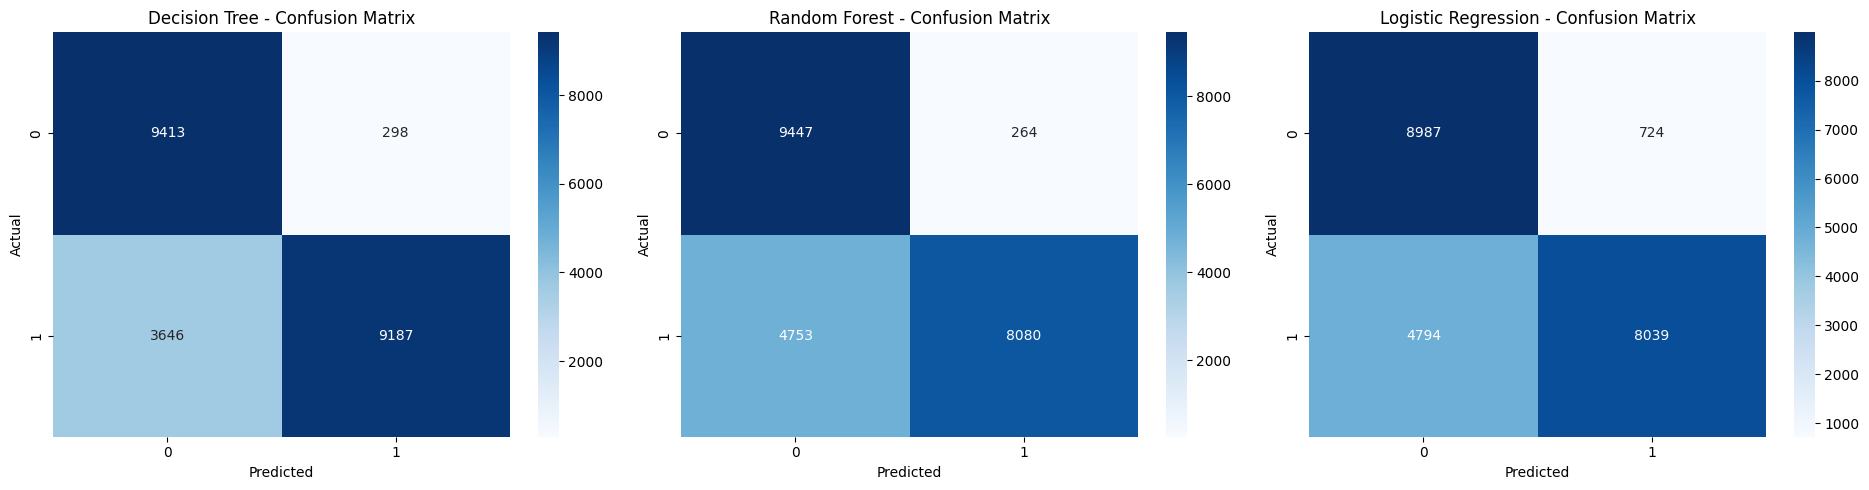

In [21]:
# Confusion matrix visualization
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(19,5))
sns.heatmap(confusion_matrix(y_test, dt_pred), annot=True, fmt='d', ax=axes[0], cmap='Blues')
axes[0].set_title('Decision Tree - Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, rf_pred), annot=True, fmt='d', ax=axes[1], cmap='Blues')
axes[1].set_title('Random Forest - Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test, lr_pred), annot=True, fmt='d', ax=axes[2], cmap='Blues')
axes[2].set_title('Logistic Regression - Confusion Matrix')
axes[2].set_xlabel('Predicted'); axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png')
plt.show()

### 7.2 Threshold Analysis (Random Forest)
By default, `predict()` classifies a connection as an attack when its predicted probability is >= 0.50. In an intrusion detection setting, the cost of a missed attack (false negative) is usually very different from the cost of a false alarm (false positive), so it is useful to see how the model behaves at other decision thresholds.

The **Random Forest** is used for this analysis. A single Decision Tree assigns each test connection the class purity of whatever leaf it lands in, and on this dataset those leaves are almost perfectly pure — its predicted probabilities are therefore concentrated at exactly 0.0 and 1.0, and sweeping the threshold barely moves the decisions at all. The Random Forest averages the votes of 100 trees, which produces a genuinely graded probability score across the full [0, 1] range and makes the threshold sweep meaningful.

Instead of a handful of hand-picked cut-offs, the threshold is swept across `np.arange(0.05, 1.00, 0.05)` — 19 values from 0.05 to 0.95. Precision, Recall, F1-score, False Positives, and False Negatives are computed at each one, exported to `threshold_analysis.csv`, and plotted in `threshold_analysis.png`.

In [22]:
# Threshold analysis on the Random Forest: its averaged 100-tree votes give a smooth
# probability distribution, so the sweep produces a meaningful trade-off curve
# (a single Decision Tree's probabilities are near-binary and barely respond to it).
threshold_model_name = 'Random Forest'
threshold_model = pipe_rf

# Reported for context: which model actually scored best on F1 in the table above
best_model_name = comparison_df['F1 Score'].idxmax()
print(f"Best-performing model by F1 Score (Section 7 table): {best_model_name}")
print(f"Model used for the threshold sweep: {threshold_model_name}")

y_prob_best = threshold_model.predict_proba(X_test)[:, 1]

# How graded are the probabilities? (contrast with a single tree's near-binary output)
dt_prob_check = pipe_dt.predict_proba(X_test)[:, 1]
print("\nShare of predicted probabilities strictly between 0.01 and 0.99:")
print(f"  Random Forest: {np.mean((y_prob_best > 0.01) & (y_prob_best < 0.99)):.3%}")
print(f"  Decision Tree: {np.mean((dt_prob_check > 0.01) & (dt_prob_check < 0.99)):.3%}")

thresholds = np.arange(0.05, 1.00, 0.05)
threshold_results = []
for t in thresholds:
    y_pred_t = (y_prob_best >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t, labels=[0, 1]).ravel()
    threshold_results.append({
        'Threshold': round(float(t), 2),
        'Precision': precision_score(y_test, y_pred_t, zero_division=0),
        'Recall': recall_score(y_test, y_pred_t, zero_division=0),
        'F1 Score': f1_score(y_test, y_pred_t, zero_division=0),
        'False Positives': fp,
        'False Negatives': fn
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df.to_csv('threshold_analysis.csv', index=False)

print(f"\nThreshold analysis for {threshold_model_name} ({len(thresholds)} thresholds):")
threshold_df

Best-performing model by F1 Score (Section 7 table): Decision Tree
Model used for the threshold sweep: Random Forest

Share of predicted probabilities strictly between 0.01 and 0.99:
  Random Forest: 33.978%
  Decision Tree: 0.022%

Threshold analysis for Random Forest (19 thresholds):


,Threshold,Precision,Recall,F1 Score,False Positives,False Negatives
0,0.05,0.919071,0.940700,0.929760,1063,761
1,0.10,0.922177,0.872594,0.896701,945,1635
2,0.15,0.953333,0.813450,0.877854,511,2394
3,0.20,0.964282,0.780488,0.862705,371,2817
4,0.25,0.965231,0.741993,0.839017,343,3311
5,0.30,0.966933,0.715499,0.822428,314,3651
6,0.35,0.967587,0.676927,0.796571,291,4146
7,0.40,0.968597,0.663368,0.787439,276,4320
8,0.45,0.968443,0.645679,0.774791,270,4547
9,0.50,0.968381,0.632432,0.765155,265,4717


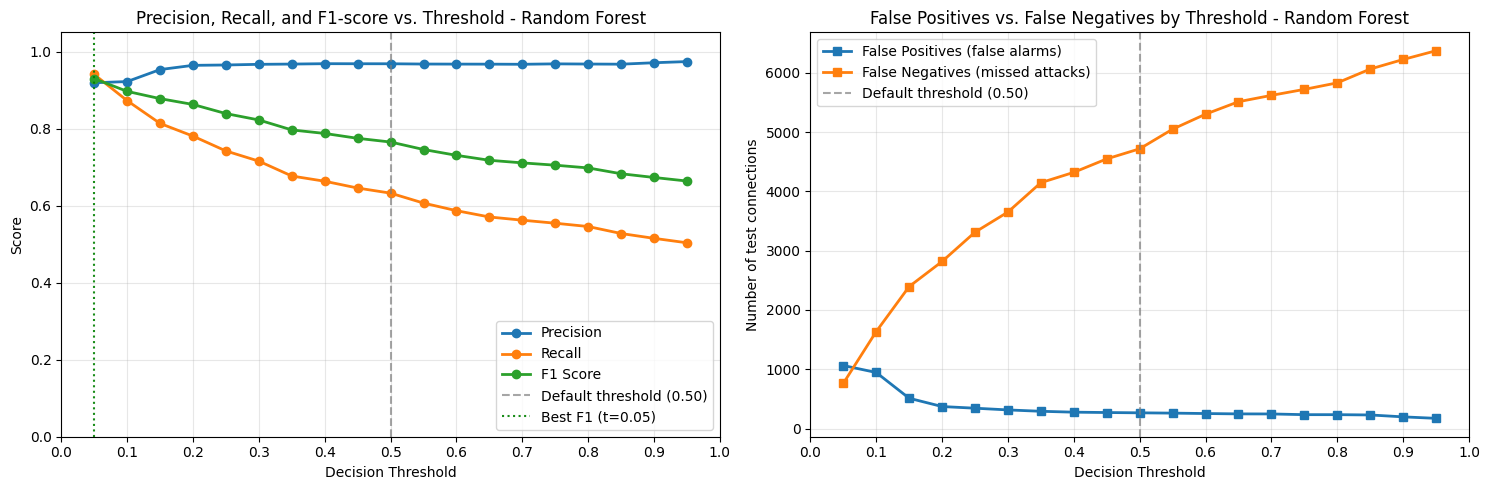

Lowest threshold  (t=0.05): recall=0.9407, precision=0.9191, FP=1063, FN=761
Default threshold (t=0.50): recall=0.6324, precision=0.9684, FP=265, FN=4717
Highest threshold (t=0.95): recall=0.5035, precision=0.9741, FP=172, FN=6371

Best F1 = 0.9298 at threshold 0.05 (recall=0.9407, precision=0.9191)
Recall change from t=0.95 to t=0.05: 0.5035 -> 0.9407 (+0.4372); missed attacks 6371 -> 761
Precision change from t=0.95 to t=0.05: 0.9741 -> 0.9191 (-0.0550); false alarms 172 -> 1063


In [23]:
# Left: Precision / Recall / F1 across the swept thresholds.
# Right: the same sweep expressed as raw error counts (false positives vs false negatives).
best_f1_row = threshold_df.loc[threshold_df['F1 Score'].idxmax()]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(threshold_df['Threshold'], threshold_df['Precision'], marker='o', linewidth=2, label='Precision')
axes[0].plot(threshold_df['Threshold'], threshold_df['Recall'], marker='o', linewidth=2, label='Recall')
axes[0].plot(threshold_df['Threshold'], threshold_df['F1 Score'], marker='o', linewidth=2, label='F1 Score')
axes[0].axvline(0.50, color='grey', linestyle='--', alpha=0.7, label='Default threshold (0.50)')
axes[0].axvline(best_f1_row['Threshold'], color='green', linestyle=':', alpha=0.9,
                label=f"Best F1 (t={best_f1_row['Threshold']:.2f})")
axes[0].set_xlabel('Decision Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title(f'Precision, Recall, and F1-score vs. Threshold - {threshold_model_name}')
axes[0].set_xticks(np.arange(0.0, 1.05, 0.1))
axes[0].set_ylim(0, 1.05)
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(threshold_df['Threshold'], threshold_df['False Positives'], marker='s', linewidth=2,
             label='False Positives (false alarms)')
axes[1].plot(threshold_df['Threshold'], threshold_df['False Negatives'], marker='s', linewidth=2,
             label='False Negatives (missed attacks)')
axes[1].axvline(0.50, color='grey', linestyle='--', alpha=0.7, label='Default threshold (0.50)')
axes[1].set_xlabel('Decision Threshold')
axes[1].set_ylabel('Number of test connections')
axes[1].set_title(f'False Positives vs. False Negatives by Threshold - {threshold_model_name}')
axes[1].set_xticks(np.arange(0.0, 1.05, 0.1))
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150)
plt.show()

# Summary printed from the computed table, so the discussion stays tied to observed values
lo, hi = threshold_df.iloc[0], threshold_df.iloc[-1]
default_row = threshold_df[threshold_df['Threshold'] == 0.50].iloc[0]
print(f"Lowest threshold  (t={lo['Threshold']:.2f}): recall={lo['Recall']:.4f}, precision={lo['Precision']:.4f}, "
      f"FP={int(lo['False Positives'])}, FN={int(lo['False Negatives'])}")
print(f"Default threshold (t=0.50): recall={default_row['Recall']:.4f}, precision={default_row['Precision']:.4f}, "
      f"FP={int(default_row['False Positives'])}, FN={int(default_row['False Negatives'])}")
print(f"Highest threshold (t={hi['Threshold']:.2f}): recall={hi['Recall']:.4f}, precision={hi['Precision']:.4f}, "
      f"FP={int(hi['False Positives'])}, FN={int(hi['False Negatives'])}")
print(f"\nBest F1 = {best_f1_row['F1 Score']:.4f} at threshold {best_f1_row['Threshold']:.2f} "
      f"(recall={best_f1_row['Recall']:.4f}, precision={best_f1_row['Precision']:.4f})")
print(f"Recall change from t=0.95 to t=0.05: {hi['Recall']:.4f} -> {lo['Recall']:.4f} "
      f"({lo['Recall'] - hi['Recall']:+.4f}); missed attacks {int(hi['False Negatives'])} -> {int(lo['False Negatives'])}")
print(f"Precision change from t=0.95 to t=0.05: {hi['Precision']:.4f} -> {lo['Precision']:.4f} "
      f"({lo['Precision'] - hi['Precision']:+.4f}); false alarms {int(hi['False Positives'])} -> {int(lo['False Positives'])}")

**Reading the results.** The sweep produces a clear and strongly asymmetric trade-off, and every statement below is taken directly from the computed table and the summary printed above.

- **Recall responds sharply to the threshold, and moves in the expected direction.** It falls steadily as the threshold rises — about 0.94 at t=0.05 down to about 0.50 at t=0.95. In raw terms, missed attacks climb from roughly 760 to over 6,300 test connections across that range. Lowering the threshold does therefore increase recall here, and substantially so.
- **Precision barely responds.** It moves only from about 0.92 at t=0.05 to about 0.97 at t=0.95 — a gain of roughly five percentage points across the entire sweep, and not even monotonically (it plateaus around 0.967-0.968 through the middle of the range and dips very slightly before recovering at the top). False alarms fall from around 1,060 to under 200.
- **F1 is highest at the lowest threshold tested** (about 0.93 at t=0.05) and decreases monotonically from there, reaching about 0.77 at the default 0.50 and about 0.66 at t=0.95.

**Why the trade-off is so lopsided.** Normal traffic is scored with very low attack probability by almost every tree in the forest, so relaxing the threshold pulls in relatively few extra false alarms. The attacks the model misses at t=0.50 are largely the unseen attack types discussed in Section 8.1 — they score low but not zero, so a lower threshold recovers a large number of them. Moving from the default 0.50 down to 0.05 trades roughly five percentage points of precision for over thirty points of recall: it adds around 800 false alarms but eliminates nearly 4,000 missed attacks.

**Implication for this use case.** For intrusion detection, a missed attack (false negative) is usually far more costly than a false alarm (false positive) — an undetected intrusion can cause real damage, while a false alarm costs analyst time. Since the low end of the sweep improves recall *and* F1 simultaneously here, it is favoured on both operational and aggregate-metric grounds, and the default 0.50 is a poor operating point for this model on this test set. A threshold in the 0.05-0.15 band is the more defensible choice: t=0.15, for instance, still holds precision above 0.95 while lifting recall to roughly 0.81. Higher thresholds only make sense for an under-staffed SOC that cannot triage many alerts, and the table above prices that decision explicitly in false positives and false negatives.

**Two caveats worth stating.** First, F1 peaks at the *edge* of the swept range rather than inside it, so the true optimum may lie below 0.05; the sweep would need to be extended to locate it, and a value that extreme should be validated before being trusted rather than read off this table alone. Second, this connects back to the model comparison in Section 7: the Random Forest looked worse than the Decision Tree on F1 *at the default threshold*, yet at t=0.05 its F1 (about 0.93) is well above the Decision Tree's default-threshold F1 (about 0.82). That is consistent with the Random Forest's much higher ROC-AUC (about 0.96 vs about 0.84), which measures ranking quality independently of any threshold. The Random Forest was ranking connections better all along — the default 0.50 cut-off was simply the wrong place to slice its probabilities, which is exactly the kind of conclusion a single-threshold comparison hides.

## 8. Error Analysis
Checking which attack categories are misclassified most often by each of the three models.

In [24]:
# Which attack categories are being missed the most?
df_test_analysis = df_test.copy()
df_test_analysis['dt_pred'] = dt_pred
df_test_analysis['rf_pred'] = rf_pred
df_test_analysis['lr_pred'] = lr_pred

# Map test labels to categories too
df_test_analysis['attack_category'] = df_test_analysis['label'].map(attack_map)
df_test_analysis['attack_category'] = df_test_analysis['attack_category'].fillna('unknown_new_attack')

print("--- Decision Tree errors by attack category ---")
errors_dt = df_test_analysis[df_test_analysis['label_binary_enc'] != df_test_analysis['dt_pred']]
print(errors_dt['attack_category'].value_counts())

print("\n--- Random Forest errors by attack category ---")
errors_rf = df_test_analysis[df_test_analysis['label_binary_enc'] != df_test_analysis['rf_pred']]
print(errors_rf['attack_category'].value_counts())

print("\n--- Logistic Regression errors by attack category ---")
errors_lr = df_test_analysis[df_test_analysis['label_binary_enc'] != df_test_analysis['lr_pred']]
print(errors_lr['attack_category'].value_counts())

--- Decision Tree errors by attack category ---
attack_category
unknown_new_attack    1966
r2l                   1592
normal                 298
dos                     58
u2r                     29
probe                    1
Name: count, dtype: int64

--- Random Forest errors by attack category ---
attack_category
unknown_new_attack    2655
r2l                   2057
normal                 264
u2r                     34
dos                      7
Name: count, dtype: int64

--- Logistic Regression errors by attack category ---
attack_category
unknown_new_attack    2188
r2l                   2173
normal                 724
dos                    350
probe                   58
u2r                     25
Name: count, dtype: int64


### 8.1 Checking for Unseen Attack Types
Comparing the attack labels present in the test set against those present in the training set, to check whether the drop in test accuracy is related to attack types the model never saw during training.

In [25]:
# Check for labels in test set NOT present in training set (root cause)
train_labels = set(df['label'].unique())
test_labels = set(df_test['label'].unique())
new_attacks_in_test = test_labels - train_labels

print("Attack types in TEST but NOT in TRAIN:", new_attacks_in_test)
print("Count of these unseen-attack rows in test set:", df_test[df_test['label'].isin(new_attacks_in_test)].shape[0])

Attack types in TEST but NOT in TRAIN: {'named', 'mailbomb', 'saint', 'sendmail', 'xsnoop', 'ps', 'xterm', 'snmpguess', 'worm', 'httptunnel', 'sqlattack', 'udpstorm', 'snmpgetattack', 'processtable', 'apache2', 'xlock', 'mscan'}
Count of these unseen-attack rows in test set: 3750


## 9. Saving Outputs
Saving the generated plots, the trained pipelines (preprocessing + model bundled together, so they can be reused for inference without needing to separately refit a scaler), and the comparison tables produced above for reference. Everything is copied into a local `project_outputs` folder and zipped into `NSL_KDD_Project_Outputs.zip` in the working directory — this uses only standard local file I/O, so it runs the same way in local Jupyter or when the notebook is executed from a GitHub clone (no Colab-specific download step required).

In [26]:
import shutil
import joblib

# Save trained pipelines (each already includes its fitted scaler, so no separate scaler artifact is needed)
joblib.dump(pipe_dt, 'decision_tree_pipeline.pkl')
joblib.dump(pipe_rf, 'random_forest_pipeline.pkl')
joblib.dump(pipe_lr, 'logistic_regression_pipeline.pkl')

# Save the cleaned/processed dataset (optional, useful for report/reproducibility)
df.to_csv('processed_train_data.csv', index=False)

# Save comparison tables generated during evaluation
comparison_df.to_csv('model_comparison.csv')
feature_set_comparison.to_csv('feature_set_comparison.csv', index=False)
threshold_df.to_csv('threshold_analysis.csv', index=False)

# Create a folder and move everything into it
import os
os.makedirs('project_outputs', exist_ok=True)

files_to_zip = [
    'class_distribution.png',
    'attack_category_distribution.png',
    'outlier_check.png',
    'correlation_heatmap.png',
    'confusion_matrices.png',
    'threshold_analysis.png',
    'decision_tree_pipeline.pkl',
    'random_forest_pipeline.pkl',
    'logistic_regression_pipeline.pkl',
    'processed_train_data.csv',
    'model_comparison.csv',
    'feature_set_comparison.csv',
    'threshold_analysis.csv'
]

for f in files_to_zip:
    if os.path.exists(f):
        shutil.copy(f, f'project_outputs/{f}')
    else:
        print(f"Warning: {f} not found, skipping")

# Zip everything into a single local archive
shutil.make_archive('NSL_KDD_Project_Outputs', 'zip', 'project_outputs')
print("Saved all models, plots, and tables to the 'project_outputs' folder and zipped them as 'NSL_KDD_Project_Outputs.zip'")

Saved all models, plots, and tables to the 'project_outputs' folder and zipped them as 'NSL_KDD_Project_Outputs.zip'


## 10. Conclusion
This notebook trains and compares three classifiers — Decision Tree, Random Forest, and Logistic Regression — for binary intrusion detection on NSL-KDD. Each model is implemented within a scikit-learn `Pipeline` whose first step is a `ColumnTransformer` applying `OneHotEncoder(handle_unknown="ignore")` to the nominal categorical columns and `StandardScaler` to the numeric ones. Because all preprocessing lives inside the pipeline, it occurs independently inside every cross-validation fold, preventing the data leakage that a global `fit_transform` performed before cross-validation would introduce. One-hot encoding is used instead of label encoding for `protocol_type`, `service`, and `flag` because these are nominal variables: integer codes would impose an artificial ordering and spacing that the data does not support, whereas one-hot encoding lets each category carry its own independent weight, and `handle_unknown="ignore"` deals with unseen test categories without a manual fallback. Cross-validation uses an explicit `StratifiedKFold` (5 folds, shuffled, random_state=42) rather than a plain fold count, so every fold preserves the same normal/attack ratio as the full training set — an important detail given how imbalanced NSL-KDD is.

A dedicated comparison in Section 6.2 checked the full feature set against the reduced feature set produced by dropping six highly-correlated raw NSL-KDD columns (correlation > 0.9, identified in Section 4.8 — these are the dataset's native engineered features, not PCA components, since no PCA is used anywhere in this notebook). Cross-validated accuracy was essentially unchanged between the two feature sets for all three models, confirming the dropped columns were genuinely redundant; the reduced set was therefore used for final training and evaluation on grounds of parsimony rather than any accuracy gain. Mean per-fold training time was also compared: it is consistently lower on the reduced set, but the saving is negligible in absolute terms at this dataset size and is not a deciding factor.

On the test set, all three models showed a noticeable drop from their training-time cross-validation scores, and error analysis (Section 8) shows this is driven largely by attack types present in the test set but never seen during training (Section 8.1) — a known characteristic of the NSL-KDD test split. A higher cross-validation score does not automatically translate into better generalization on these unseen attacks, which is why the consolidated comparison table in Section 7 (rather than training accuracy alone) is the more reliable basis for picking a model. Logistic Regression is included mainly as a linear baseline; since intrusion patterns in this dataset are not expected to be linearly separable, it is included for completeness rather than as the presumed top performer, and the actual ranking should be read directly off the comparison table.

Finally, the threshold analysis in Section 7.2 sweeps 19 decision thresholds (0.05 to 0.95) for the Random Forest, whose averaged 100-tree votes give the graded probabilities that make such a sweep meaningful — a single Decision Tree's probabilities are almost entirely saturated at 0.0 and 1.0, as the diagnostic in that section quantifies, so its decisions hardly respond to the threshold at all. The results show a strongly asymmetric trade-off: recall falls sharply as the threshold rises (roughly 0.94 down to 0.50 across the sweep), while precision moves only a few percentage points, so both F1 and recall are maximised at the low end of the range. Given that a missed intrusion is typically far more costly than a false alarm, a threshold well below the default 0.50 is the better operating point for this model — with the caveat that F1 peaks at the edge of the swept range, so the sweep would need extending to locate the true optimum. This also reframes the model comparison: the Random Forest's weaker F1 at the default threshold reflects the cut-off rather than the model, consistent with its clearly superior ROC-AUC, and the table and plot in Section 7.2 make the full cost trade-off explicit so the threshold can be tuned to whichever balance a deployment requires.